In [98]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [99]:
iris=load_iris()

In [100]:
df=pd.DataFrame(data=iris.data , columns=iris.feature_names) 

In [101]:
df['species']=iris.target

In [102]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [103]:
# removing setosa
df = df[df["species"] != 0][["sepal width (cm)", "petal length (cm)", "species"]]


In [104]:
df.head(2)

,sepal width (cm),petal length (cm),species
50,3.2,4.7,1
51,3.2,4.5,1


In [105]:
import seaborn as sns
import  matplotlib.pyplot as plt

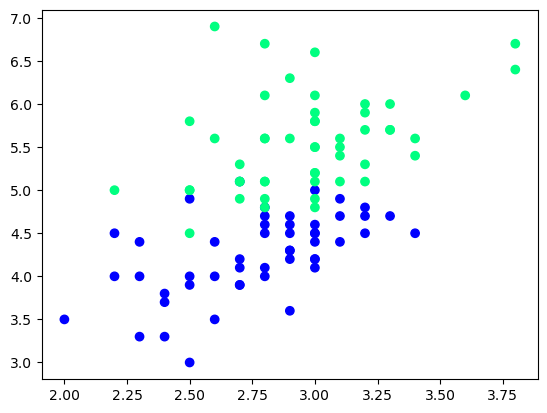

In [106]:
plt.scatter(df['sepal width (cm)'], df['petal length (cm)'], c=df['species'], cmap='winter')

In [107]:
# taking only 10 rows for training
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)


In [108]:
df_train

,sepal width (cm),petal length (cm),species
134,2.6,5.6,2
105,3.0,6.6,2
145,3.0,5.2,2
140,3.1,5.6,2
83,2.7,5.1,1
110,3.2,5.1,2
64,2.9,3.6,1
130,2.8,6.1,2
78,2.9,4.5,1
56,3.3,4.7,1


In [109]:
df_val

,sepal width (cm),petal length (cm),species
144,3.3,5.7,2
91,3.0,4.6,1
93,2.3,3.3,1
132,2.8,5.6,2
60,2.0,3.5,1


In [110]:
df_test

,sepal width (cm),petal length (cm),species
143,3.2,5.9,2
106,2.5,4.5,2
99,2.8,4.1,1
69,2.5,3.9,1
126,2.8,4.8,2


In [111]:
x_test=df_val.iloc[:,0:2].values
y_test=df_val.iloc[:,-1].values

In [112]:
x_test

array([[3.3, 5.7],
       [3. , 4.6],
       [2.3, 3.3],
       [2.8, 5.6],
       [2. , 3.5]])

# case-1 Bagging

In [113]:
# data for tree1
df_bag=df_train.sample(8,replace=True)
x=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]

In [114]:
df_bag

,sepal width (cm),petal length (cm),species
140,3.1,5.6,2
134,2.6,5.6,2
78,2.9,4.5,1
110,3.2,5.1,2
83,2.7,5.1,1
110,3.2,5.1,2
130,2.8,6.1,2
64,2.9,3.6,1


In [115]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [116]:
dt_bag1= DecisionTreeClassifier()

In [117]:
def evaluate(clf,x,y):
    clf.fit(x,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(x.values,y.values,clf=clf, legend=2)
    y_pred=clf.predict(x_test)
    print(accuracy_score(y_test,y_pred))

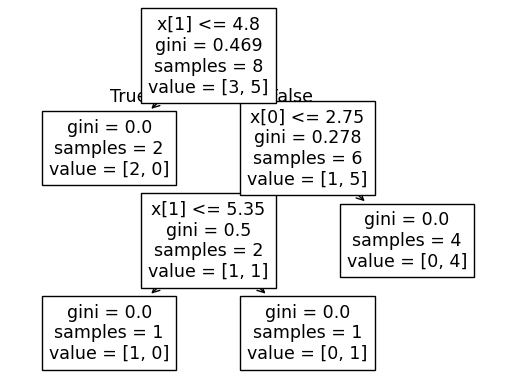

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


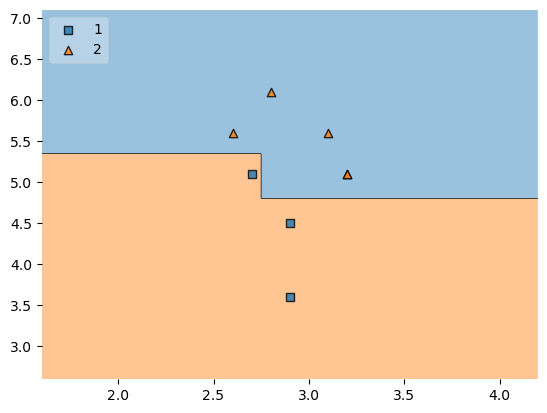

In [118]:

evaluate(dt_bag1,x,y)

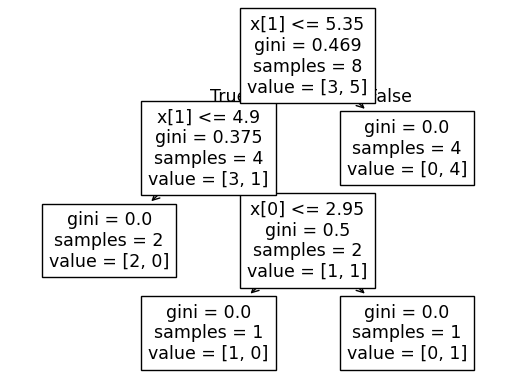

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


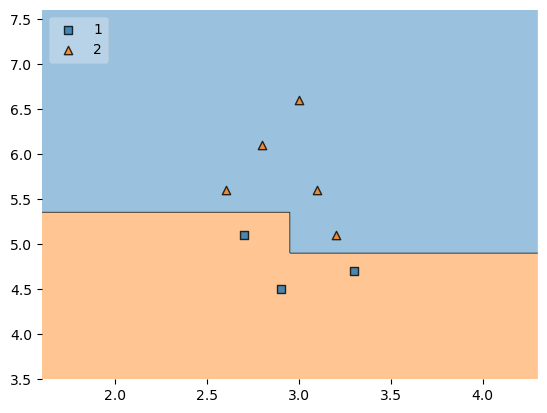

In [119]:
# data for tree2
df_bag=df_train.sample(8,replace=True)
x=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
dt_bag2= DecisionTreeClassifier()
evaluate(dt_bag2,x,y)

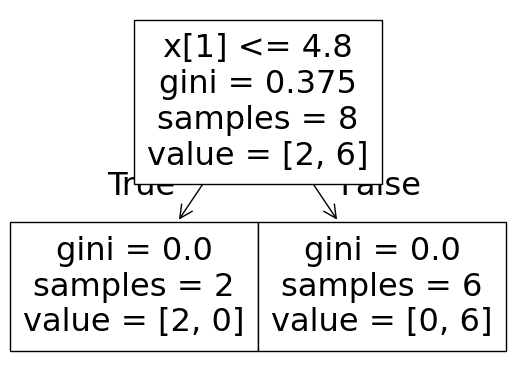

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


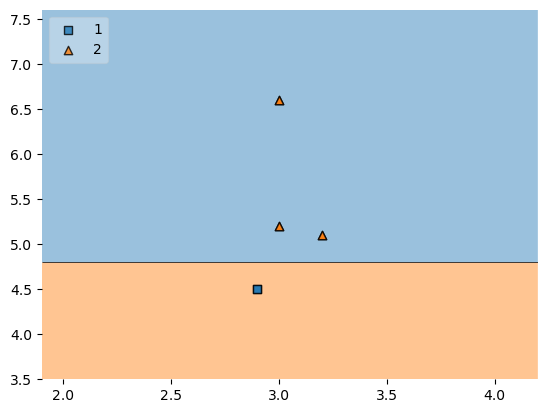

In [120]:
# data for tree3
df_bag=df_train.sample(8,replace=True)
x=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
dt_bag3= DecisionTreeClassifier()
evaluate(dt_bag3,x,y)

#### predict

In [121]:
df_test

,sepal width (cm),petal length (cm),species
143,3.2,5.9,2
106,2.5,4.5,2
99,2.8,4.1,1
69,2.5,3.9,1
126,2.8,4.8,2


In [124]:
print("predictor 1" , dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)) )
print("predictor 2" , dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)) )
print("predictor 3" , dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)) )

predictor 1 [1]
predictor 2 [1]
predictor 3 [2]


C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [125]:
# as majority is 1 that's why prediction is 1 

# Types of bagging

# PASTING- row sampling without replacement


In [127]:
df_train.sample(8)

,sepal width (cm),petal length (cm),species
78,2.9,4.5,1
140,3.1,5.6,2
110,3.2,5.1,2
134,2.6,5.6,2
64,2.9,3.6,1
145,3.0,5.2,2
130,2.8,6.1,2
83,2.7,5.1,1


# RANDOM SUBSPACES- we do column sampling instead of row sampling (can be with replacement or without replacement)

In [130]:
df1=pd.DataFrame(data=iris.data , columns=iris.feature_names) 
df1['species']=iris.target

In [131]:
df1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [132]:
df1.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
65,6.7,3.1,4.4,1.4,1
0,5.1,3.5,1.4,0.2,0
38,4.4,3.0,1.3,0.2,0
144,6.7,3.3,5.7,2.5,2
6,4.6,3.4,1.4,0.3,0
45,4.8,3.0,1.4,0.3,0
97,6.2,2.9,4.3,1.3,1
46,5.1,3.8,1.6,0.2,0
43,5.0,3.5,1.6,0.6,0
125,7.2,3.2,6.0,1.8,2


In [135]:
df1.sample(2,replace=True,axis=1)

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


# RANDOM PATCHES- BOTH ROW and column sampling is done

In [136]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [138]:
df1.sample(8,replace=True).sample(2, replace=True,axis=1)

,sepal length (cm),species
59,5.2,1
4,5.0,0
2,4.7,0
111,6.4,2
75,6.6,1
19,5.1,0
91,6.1,1
134,6.1,2
